<a href="https://colab.research.google.com/github/asmaatefomran/generative-ai-tasks/blob/main/Task9_web_chat_interface.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Task 9: Web Chat Interface for an AI Agent**

 Install

In [1]:
!pip install -q gradio groq


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 6.5 MB/s eta 0:00:00


Setup Groq

In [24]:
import os
from google.colab import userdata
from groq import Groq

os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")

client = Groq(api_key=os.environ["GROQ_API_KEY"])


#Create the AI agent

The agent receives the user's message and conversation history

In [29]:
def ai_agent(user_message, conversation_history):
    messages = []
    for turn in conversation_history:
        if isinstance(turn, dict):
            messages.append({"role": turn["role"], "content": turn["content"]})
        else:
            user_msg, agent_msg = turn
            messages.append({"role": "user", "content": user_msg})
            messages.append({"role": "assistant", "content": agent_msg})
    messages.append({"role": "user", "content": user_message})

    response = client.chat.completions.create(
        model="openai/gpt-oss-120b",
        messages=messages,
        max_tokens=500
    )

    return response.choices[0].message.content

#Create the web interface

In [31]:
import gradio as gr

def chat_fn(message, history):
    """
    Gradio calls this every time the user sends a message.
    'history' is maintained automatically by Gradio.
    """
    reply = ai_agent(message, history)
    return reply

demo = gr.ChatInterface(
    fn=chat_fn,
    title="AI Agent Chat",
    description="Chat with your AI agent below. Conversation history is preserved automatically.",
    examples=["Hello, who are you?", "What can you help me with?"]
)

demo.launch(share=True)  # gives you a public link from Colab

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://dfd5d4966651bcbfa8.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


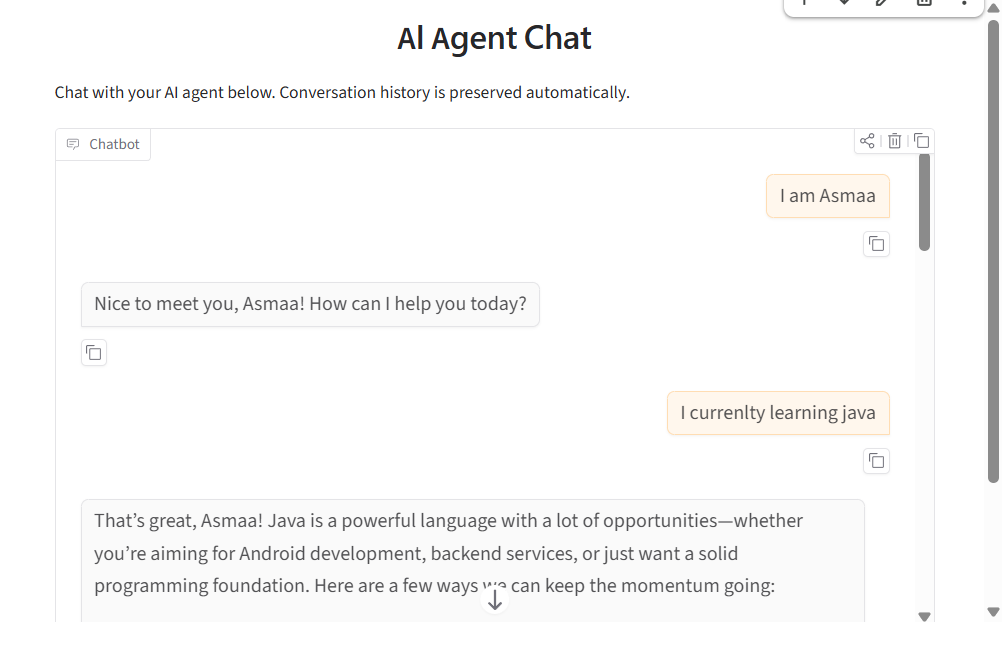)

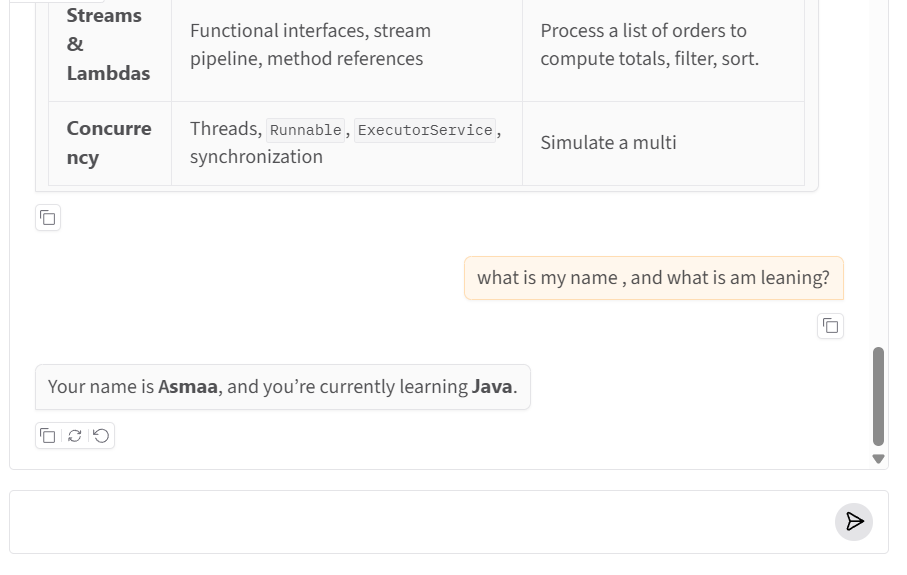